## 4. Modelling and Evaluation

This notebook loads the processed data saved by 01_data_preparation.ipynb
and carries out model comparison, hyperparameter tuning, final evaluation,
and model saving.

### Load Processed Data

In [1]:
import numpy as np
import joblib
 
X_train = np.load("processed_data/X_train.npy")
X_val = np.load("processed_data/X_val.npy")
X_test = np.load("processed_data/X_test.npy")
y_train = np.load("processed_data/y_train.npy")
y_val = np.load("processed_data/y_val.npy")
y_test = np.load("processed_data/y_test.npy")
 
le = joblib.load("processed_data/label_encoder.joblib")
scaler = joblib.load("processed_data/scaler.joblib")
feature_names = joblib.load("processed_data/feature_names.joblib")
 
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Classes:", list(le.classes_))

Train: (1412397, 69) Val: (302656, 69) Test: (302657, 69)
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - XSS']


## 4.1 Candidate Model 1: Random Forest

In [2]:
# Train Random Forest baseline

from sklearn.ensemble import RandomForestClassifier
import time
 
start = time.time()
 
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
 
print(f"Training time: {round((time.time() - start) / 60, 2)} minutes")

Training time: 0.81 minutes


In [3]:
# Evaluate Random Forest on validation set 
 
from sklearn.metrics import accuracy_score, f1_score, classification_report
 
val_preds = rf_model.predict(X_val)
 
print("Validation accuracy:", round(accuracy_score(y_val, val_preds), 4))
print("Validation macro F1:", round(f1_score(y_val, val_preds, average="macro"), 4))
print("Validation weighted F1:", round(f1_score(y_val, val_preds, average="weighted"), 4))
 
print("\nFull classification report:")
print(classification_report(y_val, val_preds, target_names=le.classes_))

Validation accuracy: 0.9944
Validation macro F1: 0.8664
Validation weighted F1: 0.9958

Full classification report:
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.99      1.00    238896
                     Bot       0.20      1.00      0.33       292
                    DDoS       1.00      1.00      1.00     19201
           DoS GoldenEye       0.99      1.00      0.99      1543
                DoS Hulk       1.00      1.00      1.00     25921
        DoS Slowhttptest       0.99      0.99      0.99       784
           DoS slowloris       1.00      0.99      0.99       808
             FTP-Patator       1.00      1.00      1.00       890
                PortScan       0.99      1.00      0.99     13519
             SSH-Patator       1.00      1.00      1.00       483
Web Attack - Brute Force       0.76      0.62      0.68       221
        Web Attack - XSS       0.32      0.58      0.41        98

                accuracy

In [4]:
# Feature importance
import pandas as pd
 
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)
 
print("Top 15 most important features:")
print(importances.head(15))

Top 15 most important features:
Destination Port           0.065461
Init_Win_bytes_backward    0.056982
Fwd Packet Length Max      0.033021
Bwd Header Length          0.030359
Flow IAT Mean              0.029092
Flow IAT Std               0.026217
Fwd IAT Mean               0.026171
Init_Win_bytes_forward     0.026028
Average Packet Size        0.024299
Max Packet Length          0.023123
Fwd IAT Std                0.023122
Flow IAT Max               0.022817
Subflow Fwd Bytes          0.022217
Subflow Bwd Packets        0.020250
min_seg_size_forward       0.020074
dtype: float64


## 4.2 Candidate Model 2: XGBoost

In [5]:
# Compute balanced sample weights

from sklearn.utils.class_weight import compute_sample_weight
 
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
print("Sample weight range:", sample_weights.min(), "to", sample_weights.max())

Sample weight range: 0.10557480084711175 to 258.11348684210526


In [6]:
# Train XGBoost 
 
import xgboost as xgb
import time
 
start = time.time()
 
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)
 
xgb_model.fit(X_train, y_train, sample_weight=sample_weights)
 
print(f"Training time: {round((time.time() - start) / 60, 2)} minutes")

Training time: 2.28 minutes


In [7]:
# Evaluate XGBoost on validation set
from sklearn.metrics import accuracy_score, f1_score, classification_report
 
val_preds_xgb = xgb_model.predict(X_val)
 
print("XGBoost validation accuracy:", round(accuracy_score(y_val, val_preds_xgb), 4))
print("XGBoost validation macro F1:", round(f1_score(y_val, val_preds_xgb, average="macro"), 4))
print("XGBoost validation weighted F1:", round(f1_score(y_val, val_preds_xgb, average="weighted"), 4))
 
print("\nFull classification report:")
print(classification_report(y_val, val_preds_xgb, target_names=le.classes_))

XGBoost validation accuracy: 0.9976
XGBoost validation macro F1: 0.9021
XGBoost validation weighted F1: 0.9978

Full classification report:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    238896
                     Bot       0.53      1.00      0.69       292
                    DDoS       1.00      1.00      1.00     19201
           DoS GoldenEye       0.98      1.00      0.99      1543
                DoS Hulk       1.00      1.00      1.00     25921
        DoS Slowhttptest       0.97      0.99      0.98       784
           DoS slowloris       0.99      0.99      0.99       808
             FTP-Patator       1.00      1.00      1.00       890
                PortScan       0.99      1.00      0.99     13519
             SSH-Patator       1.00      1.00      1.00       483
Web Attack - Brute Force       0.74      0.66      0.70       221
        Web Attack - XSS       0.42      0.58      0.49        98



## 4.3 Comparison and Final Choice

In [8]:
# Side-by-side comparison with Random Forest
 
import pandas as pd
 
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Validation Accuracy": [
        accuracy_score(y_val, val_preds),
        accuracy_score(y_val, val_preds_xgb)
    ],
    "Validation Macro F1": [
        f1_score(y_val, val_preds, average="macro"),
        f1_score(y_val, val_preds_xgb, average="macro")
    ],
    "Validation Weighted F1": [
        f1_score(y_val, val_preds, average="weighted"),
        f1_score(y_val, val_preds_xgb, average="weighted")
    ],
})
print(comparison)

           Model  Validation Accuracy  Validation Macro F1  \
0  Random Forest             0.994446             0.866431   
1        XGBoost             0.997598             0.902052   

   Validation Weighted F1  
0                0.995825  
1                0.997751  


In [9]:
importances_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names)
importances_xgb = importances_xgb.sort_values(ascending=False)
 
print("Top 15 most important features (XGBoost):")
print(importances_xgb.head(15))

Top 15 most important features (XGBoost):
Bwd Packet Length Min          0.163512
Bwd Header Length              0.101771
Active Mean                    0.058968
Bwd IAT Std                    0.046950
PSH Flag Count                 0.045912
Destination Port               0.044920
Fwd IAT Std                    0.043483
Fwd Packet Length Max          0.040477
Flow IAT Mean                  0.039200
min_seg_size_forward           0.035291
Flow Duration                  0.029365
Init_Win_bytes_backward        0.027565
Total Length of Bwd Packets    0.026334
Bwd IAT Min                    0.025055
Bwd Packets/s                  0.021054
dtype: float32


## 5.2 Hyperparameter Tuning Strategy

In [10]:
# Create a stratified tuning subsample 
 
from sklearn.model_selection import train_test_split
 
TUNE_SAMPLE_SIZE = 40000  # adjust this if needed based on how fast it runs
 
X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=TUNE_SAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)
print("Tuning subsample shape:", X_tune.shape)

Tuning subsample shape: (40000, 69)


In [11]:
# Define the search space and run RandomizedSearchCV 

 
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import time
 
tune_weights = compute_sample_weight(class_weight="balanced", y=y_tune)
 
param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}
 
base_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)
 
N_ITER = 12   # number of random hyperparameter combinations to try
CV_FOLDS = 3  # cross-validation folds per combination
 
search = RandomizedSearchCV(
    base_model,
    param_distributions=param_dist,
    n_iter=N_ITER,
    cv=CV_FOLDS,
    scoring="f1_macro",
    random_state=42,
    n_jobs=1,       # keep this at 1; XGBoost already parallelises internally via n_jobs=-1 above
    verbose=2
)
 
start = time.time()
search.fit(X_tune, y_tune, sample_weight=tune_weights)
elapsed = time.time() - start
 
print(f"\nSearch completed in {round(elapsed/60, 2)} minutes")
print("Best parameters found:", search.best_params_)
print("Best cross-validated macro F1:", round(search.best_score_, 4))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=10, n_estimators=100, subsample=0.8; total time=   4.3s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=10, n_estimators=100, subsample=0.8; total time=   4.7s
[CV] END colsample_bytree=1.0, learning_rate=0.2, max_depth=10, n_estimators=100, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.7; total time=   6.9s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.7; total time=   6.8s
[CV] END colsample_bytree=0.7, learning_rate=0.1, max_depth=4, n_estimators=200, subsample=0.7; total time=   6.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.7; total time=   3.7s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=4, n_estimators=100, subsample=0.7; total time=   3.6s
[CV] END colsa

## 5.3 Final Parameters and Justification

In [12]:
# Retrain final model on the FULL training set with best params 
 
full_weights = compute_sample_weight(class_weight="balanced", y=y_train)
 
final_model = xgb.XGBClassifier(
    **search.best_params_,
    objective="multi:softmax",
    num_class=len(le.classes_),
    random_state=42,
    n_jobs=-1,
    eval_metric="mlogloss"
)
 
start = time.time()
final_model.fit(X_train, y_train, sample_weight=full_weights)
print(f"\nFinal model trained on full training set in {round((time.time()-start)/60, 2)} minutes")
 


Final model trained on full training set in 2.78 minutes


In [13]:
# Compare tuned model against the earlier default-parameter XGBoost
from sklearn.metrics import accuracy_score, f1_score
 
val_preds_tuned = final_model.predict(X_val)
 
print("\nTuned XGBoost validation accuracy:", round(accuracy_score(y_val, val_preds_tuned), 4))
print("Tuned XGBoost validation macro F1:", round(f1_score(y_val, val_preds_tuned, average="macro"), 4))
 
print("\nFor comparison, default-parameter XGBoost had:")
print("Validation accuracy:", round(accuracy_score(y_val, val_preds_xgb), 4))
print("Validation macro F1:", round(f1_score(y_val, val_preds_xgb, average="macro"), 4))
 


Tuned XGBoost validation accuracy: 0.9984
Tuned XGBoost validation macro F1: 0.9128

For comparison, default-parameter XGBoost had:
Validation accuracy: 0.9976
Validation macro F1: 0.9021


## 6.2 Test Set Performance

In [14]:
# Generate predictions on the test set
 
test_preds = final_model.predict(X_test)
 
 
# --- 9.2 Core metrics ---
 
from sklearn.metrics import accuracy_score, f1_score, classification_report
 
print("Test set accuracy:", round(accuracy_score(y_test, test_preds), 4))
print("Test set macro F1:", round(f1_score(y_test, test_preds, average="macro"), 4))
print("Test set weighted F1:", round(f1_score(y_test, test_preds, average="weighted"), 4))
 
print("\nFull classification report on test set:")
print(classification_report(y_test, test_preds, target_names=le.classes_))

Test set accuracy: 0.9984
Test set macro F1: 0.9136
Test set weighted F1: 0.9984

Full classification report on test set:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    238896
                     Bot       0.68      0.99      0.81       292
                    DDoS       1.00      1.00      1.00     19202
           DoS GoldenEye       0.99      1.00      0.99      1543
                DoS Hulk       1.00      1.00      1.00     25922
        DoS Slowhttptest       0.99      1.00      0.99       784
           DoS slowloris       0.99      1.00      1.00       808
             FTP-Patator       1.00      1.00      1.00       889
                PortScan       0.99      1.00      0.99     13520
             SSH-Patator       1.00      1.00      1.00       483
Web Attack - Brute Force       0.76      0.75      0.75       220
        Web Attack - XSS       0.43      0.44      0.43        98

                ac

## 6.3 Confusion Matrix Analysis

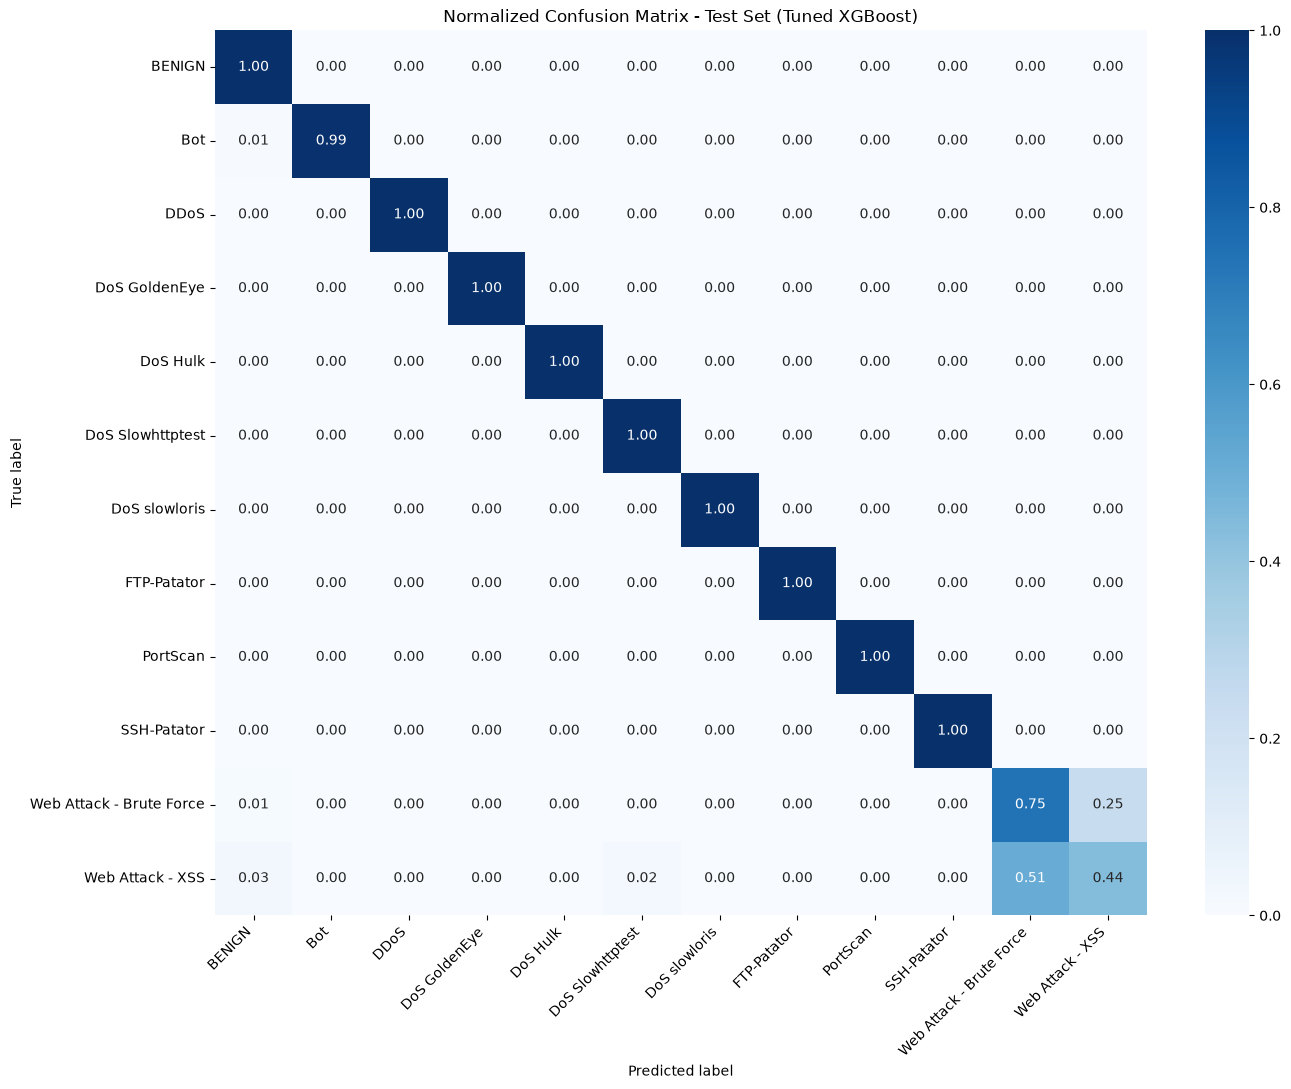

Confusion matrix saved as confusion_matrix_test.png


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
 
cm = confusion_matrix(y_test, test_preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
 
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues",
    ax=ax
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Normalized Confusion Matrix - Test Set (Tuned XGBoost)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix_test.png", dpi=150)
plt.show()
 
print("Confusion matrix saved as confusion_matrix_test.png")
 

## 6.4 Per-Class Performance and Imbalance Impact

In [16]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
 
precision, recall, f1, support = precision_recall_fscore_support(y_test, test_preds)
 
results_table = pd.DataFrame({
    "Class": le.classes_,
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
})
print(results_table)
 
results_table.to_csv("test_set_results_per_class.csv", index=False)
print("\nSaved per-class results to test_set_results_per_class.csv")

                       Class  Precision    Recall  F1-Score  Support
0                     BENIGN   0.999954  0.998602  0.999277   238896
1                        Bot   0.677570  0.993151  0.805556      292
2                       DDoS   0.999948  1.000000  0.999974    19202
3              DoS GoldenEye   0.985934  0.999352  0.992597     1543
4                   DoS Hulk   0.998959  0.999228  0.999094    25922
5           DoS Slowhttptest   0.986129  0.997449  0.991756      784
6              DoS slowloris   0.993827  0.996287  0.995056      808
7                FTP-Patator   1.000000  1.000000  1.000000      889
8                   PortScan   0.988368  0.999260  0.993784    13520
9                SSH-Patator   1.000000  1.000000  1.000000      483
10  Web Attack - Brute Force   0.759259  0.745455  0.752294      220
11          Web Attack - XSS   0.430000  0.438776  0.434343       98

Saved per-class results to test_set_results_per_class.csv


In [17]:
print("\nValidation macro F1:", round(f1_score(y_val, val_preds_tuned, average="macro"), 4))
print("Test macro F1:", round(f1_score(y_test, test_preds, average="macro"), 4))


Validation macro F1: 0.9128
Test macro F1: 0.9136


## Save the Final Model

In [18]:
import joblib
import os
 
os.makedirs("saved_model", exist_ok=True)
 
joblib.dump(final_model, "saved_model/final_xgboost_model.joblib")
joblib.dump(scaler, "saved_model/scaler.joblib")
joblib.dump(le, "saved_model/label_encoder.joblib")
joblib.dump(feature_names, "saved_model/feature_names.joblib")
 
print("Model and supporting objects saved to saved_model/")
print(os.listdir("saved_model"))

Model and supporting objects saved to saved_model/
['feature_names.joblib', 'final_xgboost_model.joblib', 'label_encoder.joblib', 'scaler.joblib']


## Reproducibility Demonstration

The following two cells confirm the saved model can be reloaded
independently and produces identical results to those reported above.

In [19]:
import joblib
import numpy as np
from sklearn.metrics import accuracy_score, classification_report
# load the saved model and supporting objects
loaded_model = joblib.load("saved_model/final_xgboost_model.joblib")
loaded_scaler = joblib.load("saved_model/scaler.joblib")
loaded_le = joblib.load("saved_model/label_encoder.joblib")
 
# load the held-out test set saved earlier in 01_data_preparation.ipynb

X_test_loaded = np.load("processed_data/X_test.npy")
y_test_loaded = np.load("processed_data/y_test.npy")
 
# run predictions exactly as presented in the report
test_predictions = loaded_model.predict(X_test_loaded)
test_predictions_labels = loaded_le.inverse_transform(test_predictions)
 
print("Sample predictions (first 10):")
print(test_predictions_labels[:10])
 
print("\nReproduced test set accuracy:", round(accuracy_score(y_test_loaded, test_predictions), 4))
print("\nReproduced classification report:")
print(classification_report(y_test_loaded, test_predictions, target_names=loaded_le.classes_))

Sample predictions (first 10):
['DoS Hulk' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN' 'BENIGN'
 'BENIGN' 'BENIGN']

Reproduced test set accuracy: 0.9984

Reproduced classification report:
                          precision    recall  f1-score   support

                  BENIGN       1.00      1.00      1.00    238896
                     Bot       0.68      0.99      0.81       292
                    DDoS       1.00      1.00      1.00     19202
           DoS GoldenEye       0.99      1.00      0.99      1543
                DoS Hulk       1.00      1.00      1.00     25922
        DoS Slowhttptest       0.99      1.00      0.99       784
           DoS slowloris       0.99      1.00      1.00       808
             FTP-Patator       1.00      1.00      1.00       889
                PortScan       0.99      1.00      0.99     13520
             SSH-Patator       1.00      1.00      1.00       483
Web Attack - Brute Force       0.76      0.75      0.75       220
        

In [20]:
# Demonstration: predicting on a single new flow record 

sample_row = X_test_loaded[0].reshape(1, -1)  # already scaled, since X_test was saved post-scaling
true_label = loaded_le.inverse_transform([y_test_loaded[0]])[0]
 
prediction = loaded_model.predict(sample_row)
predicted_label = loaded_le.inverse_transform(prediction)[0]
 
print(f"\nSingle-sample demonstration:")
print(f"True label: {true_label}")
print(f"Predicted label: {predicted_label}")


Single-sample demonstration:
True label: DoS Hulk
Predicted label: DoS Hulk
